In [1]:
import pandas as pd

# Load the file
df = pd.read_csv('cost-of-tax-collection.csv')

# Inspect data
print("--- HEAD ---")
print(df.head())
print("\n--- INFO ---")
print(df.info())

--- HEAD ---
   financial_year  cost_per_dollar_of_tax_collected
0            2000                              0.87
1            2001                              0.90
2            2002                              0.99
3            2003                              1.01
4            2004                              1.02

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   financial_year                    20 non-null     int64  
 1   cost_per_dollar_of_tax_collected  20 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 452.0 bytes
None


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('cost-of-tax-collection.csv')

# Calculate YoY Return (percentage change)
df['yoy_return'] = df['cost_per_dollar_of_tax_collected'].pct_change()

# Calculate Trend (e.g., rolling average or just basic statistics over time)
df['3_year_moving_avg'] = df['cost_per_dollar_of_tax_collected'].rolling(window=3).mean()

# Summary statistics
print("Summary Statistics:")
print(df.describe())

# Correlation Matrix
corr = df[['financial_year', 'cost_per_dollar_of_tax_collected', 'yoy_return']].corr()
print("\nCorrelation Matrix:")
print(corr)

# Save the transformed dataframe to a new CSV for the user to use in PowerBI
df.to_csv('transformed_tax_collection_data.csv', index=False)
print("\nTransformed data saved to 'transformed_tax_collection_data.csv'")

Summary Statistics:
       financial_year  cost_per_dollar_of_tax_collected  yoy_return  \
count        20.00000                         20.000000   19.000000   
mean       2009.50000                          0.860500   -0.003830   
std           5.91608                          0.075844    0.063115   
min        2000.00000                          0.770000   -0.107527   
25%        2004.75000                          0.800000   -0.047065   
50%        2009.50000                          0.840000    0.009901   
75%        2014.25000                          0.885000    0.027342   
max        2019.00000                          1.020000    0.100000   

       3_year_moving_avg  
count          18.000000  
mean            0.863519  
std             0.066357  
min             0.800000  
25%             0.818333  
50%             0.836667  
75%             0.902500  
max             1.006667  

Correlation Matrix:
                                  financial_year  \
financial_year          

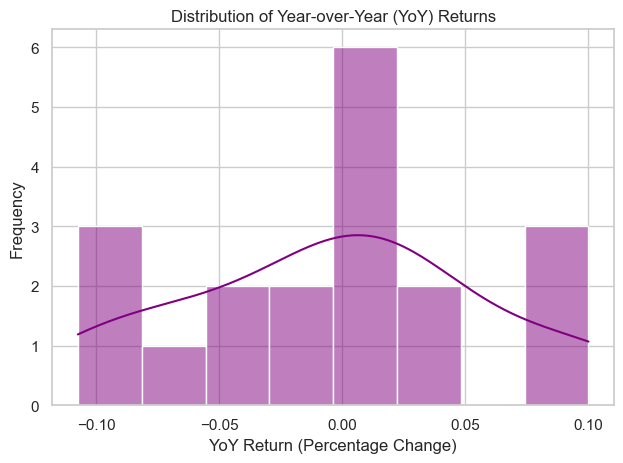

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

# 1. Trend Plot
plt.clf()
plt.plot(df['financial_year'], df['cost_per_dollar_of_tax_collected'], marker='o', color='b', label='Cost per Dollar')
plt.plot(df['financial_year'], df['3_year_moving_avg'], linestyle='--', color='r', label='3-Year Moving Avg')
plt.title('Cost per Dollar of Tax Collected Trend (2000-2019)')
plt.xlabel('Financial Year')
plt.ylabel('Cost per Dollar ($)')
plt.xticks(df['financial_year'], rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('tax_collection_trend.png')

# 2. Correlation Heatmap
plt.clf()
corr_matrix = df[['financial_year', 'cost_per_dollar_of_tax_collected', 'yoy_return']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')

# 3. Return Distribution Plot
plt.clf()
sns.histplot(df['yoy_return'].dropna(), kde=True, color='purple', bins=8)
plt.title('Distribution of Year-over-Year (YoY) Returns')
plt.xlabel('YoY Return (Percentage Change)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('return_distribution.png')